In [1]:
import numpy as np 
import esam
from FDMT_tests import simulate_narrow_frb as snf
from pylab import *
%matplotlib inline

# do automatic reloading
%load_ext autoreload
%autoreload 2


In [2]:
ls -lrth ../*.npy

-rw-rw-r-- 1 ban115 ban115  70K Jan  5 14:32 ../final_optimised_esam_tree_fast_with_traces_0_1000_0.1_nch256_threshold_0.9.pkl.npy
-rw-rw-r-- 1 ban115 ban115 144K Jan  5 14:33 ../final_optimised_esam_tree_fast_with_traces_0_1000_0.5_nch256_threshold_0.85.pkl.npy
-rw-rw-r-- 1 ban115 ban115 506K Jan  5 19:59 ../final_optimised_esam_tree_fast_with_traces_0_3000_0.2_nch256_threshold_0.85.pkl.npy


In [3]:
tree = np.load('../test_data/final_optimised_esam_tree_fast_with_traces_0_1000_0.2_nch256_threshold_0.85.pkl.npy', allow_pickle=True)
# unwrap from nd array
tree = tree.item()

In [4]:
prod_last = tree._products[-1]

In [5]:
prod_last.offset

-142

256.0 1.0 (1, 104)


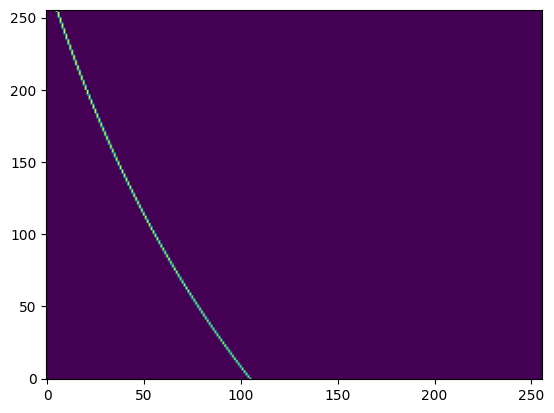

In [6]:
nch = 256
fchans = np.linspace(800.5, 1055.5, nch, endpoint=True, dtype=np.float32)
tx = 100
nsamps = 256
nch = 256
tx = 1
dm = 100
chw_2 = 0.5
tpulse = dm + 5.5
#tpulse = 10
din, ndd = snf.make_pure_frb(nsamps, nch, tx, dm, fchans, chw_2, tpulse)
assert(not np.all(din == 0))
imshow(din, aspect='auto', origin='lower')
print(sum(din), din.max(), np.unravel_index(np.argmax(din), din.shape))

In [7]:
sum(din)

256.0

2 me=0:1 target=0:256 upper?False lower? False early?False
2 me=2:3 target=0:256 upper?False lower? False early?False
4 me=0:3 target=0:256 upper?False lower? False early?False
2 me=4:5 target=0:256 upper?False lower? False early?False
2 me=6:7 target=0:256 upper?False lower? False early?False
4 me=4:7 target=0:256 upper?False lower? False early?False
8 me=0:7 target=0:256 upper?False lower? False early?False
2 me=8:9 target=0:256 upper?False lower? False early?False
2 me=10:11 target=0:256 upper?False lower? False early?False
4 me=8:11 target=0:256 upper?False lower? False early?False
2 me=12:13 target=0:256 upper?False lower? False early?False
2 me=14:15 target=0:256 upper?False lower? False early?False
4 me=12:15 target=0:256 upper?False lower? False early?False
8 me=8:15 target=0:256 upper?False lower? False early?False
16 me=0:15 target=0:256 upper?False lower? False early?False
2 me=16:17 target=0:256 upper?False lower? False early?False
2 me=18:19 target=0:256 upper?False lower?

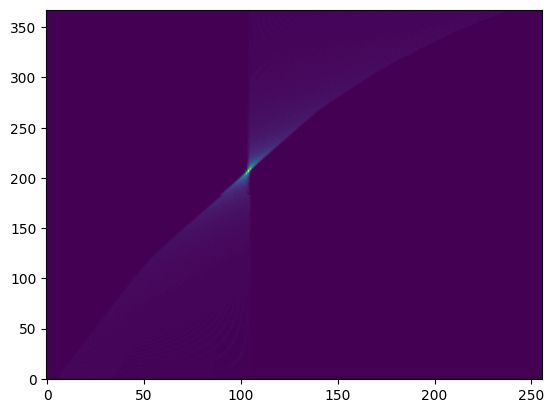

In [8]:
dout = tree(din)
figure()
imshow(dout[:,:], aspect='auto', origin='lower')
print(dout.argmax())


2 me=0:1 target=0:256 upper?False lower? False early?False
2 me=2:3 target=0:256 upper?False lower? False early?False
4 me=0:3 target=0:256 upper?False lower? False early?False
2 me=4:5 target=0:256 upper?False lower? False early?False
2 me=6:7 target=0:256 upper?False lower? False early?False
4 me=4:7 target=0:256 upper?False lower? False early?False
8 me=0:7 target=0:256 upper?False lower? False early?False
2 me=8:9 target=0:256 upper?False lower? False early?False
2 me=10:11 target=0:256 upper?False lower? False early?False
4 me=8:11 target=0:256 upper?False lower? False early?False
2 me=12:13 target=0:256 upper?False lower? False early?False
2 me=14:15 target=0:256 upper?False lower? False early?False
4 me=12:15 target=0:256 upper?False lower? False early?False
8 me=8:15 target=0:256 upper?False lower? False early?False
16 me=0:15 target=0:256 upper?False lower? False early?False
2 me=16:17 target=0:256 upper?False lower? False early?False
2 me=18:19 target=0:256 upper?False lower?

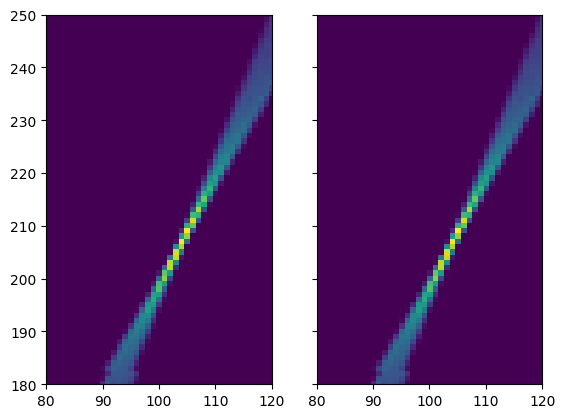

In [9]:
start_chan = 129
end_chan = start_chan + 100
nch = end_chan - start_chan + 1
d2 = np.zeros_like(din)
d2[start_chan:end_chan+1,:] = din[start_chan:end_chan+1,:]
fig, ax = subplots(1,2, sharex=True, sharey=True)
dout1 = tree(d2)
dout2 = tree(din, lower_chan=start_chan, upper_chan=end_chan)
ax[1].imshow(dout1, aspect='auto', origin='lower')
ax[0].imshow(dout2, aspect='auto', origin='lower')
ax[0].set_xlim(80, 120)
ax[1].set_ylim(180,250)
np.testing.assert_allclose(dout1, dout2)


2 me=0:1 target=0:256 upper?False lower? False early?False
2 me=2:3 target=0:256 upper?False lower? False early?False
4 me=0:3 target=0:256 upper?False lower? False early?False
2 me=4:5 target=0:256 upper?False lower? False early?False
2 me=6:7 target=0:256 upper?False lower? False early?False
4 me=4:7 target=0:256 upper?False lower? False early?False
8 me=0:7 target=0:256 upper?False lower? False early?False
2 me=8:9 target=0:256 upper?False lower? False early?False
2 me=10:11 target=0:256 upper?False lower? False early?False
4 me=8:11 target=0:256 upper?False lower? False early?False
2 me=12:13 target=0:256 upper?False lower? False early?False
2 me=14:15 target=0:256 upper?False lower? False early?False
4 me=12:15 target=0:256 upper?False lower? False early?False
8 me=8:15 target=0:256 upper?False lower? False early?False
16 me=0:15 target=0:256 upper?False lower? False early?False
2 me=16:17 target=0:256 upper?False lower? False early?False
2 me=18:19 target=0:256 upper?False lower?

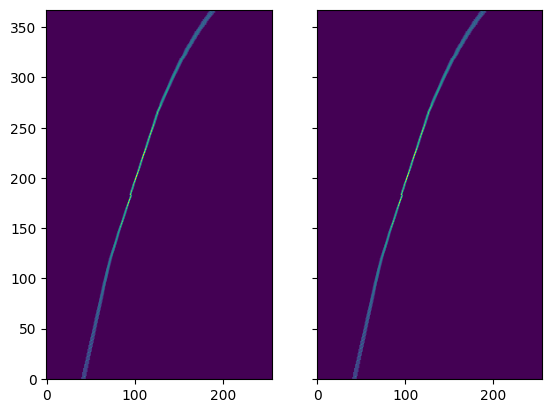

In [10]:
start_chan = 129
end_chan = start_chan + 12
nch = end_chan - start_chan + 1
d2 = np.zeros_like(din)
d2[start_chan:end_chan+1,:] = din[start_chan:end_chan+1,:]
fig, ax = subplots(1,2, sharex=True, sharey=True)
dout1 = tree(d2)
dout2 = tree(din, lower_chan=start_chan, upper_chan=end_chan)
ax[1].imshow(dout1, aspect='auto', origin='lower')
ax[0].imshow(dout2, aspect='auto', origin='lower')
#ax[0].set_xlim(80, 120)
#ax[1].set_ylim(180,250)
np.testing.assert_allclose(dout1, dout2)

In [11]:
%timeit dout = tree(din)

2 me=0:1 target=0:256 upper?False lower? False early?False
2 me=2:3 target=0:256 upper?False lower? False early?False
4 me=0:3 target=0:256 upper?False lower? False early?False
2 me=4:5 target=0:256 upper?False lower? False early?False
2 me=6:7 target=0:256 upper?False lower? False early?False
4 me=4:7 target=0:256 upper?False lower? False early?False
8 me=0:7 target=0:256 upper?False lower? False early?False
2 me=8:9 target=0:256 upper?False lower? False early?False
2 me=10:11 target=0:256 upper?False lower? False early?False
4 me=8:11 target=0:256 upper?False lower? False early?False
2 me=12:13 target=0:256 upper?False lower? False early?False
2 me=14:15 target=0:256 upper?False lower? False early?False
4 me=12:15 target=0:256 upper?False lower? False early?False
8 me=8:15 target=0:256 upper?False lower? False early?False
16 me=0:15 target=0:256 upper?False lower? False early?False
2 me=16:17 target=0:256 upper?False lower? False early?False
2 me=18:19 target=0:256 upper?False lower?

In [ ]:
%timeit dout2 = tree(din, lower_chan=start_chan, upper_chan=start_chan+15)


2 me=128:129 target=129:1744 upper?False lower? True early?False
2 me=130:131 target=129:1744 upper?False lower? False early?False
4 me=128:131 target=129:1744 upper?False lower? False early?False
2 me=132:133 target=129:1744 upper?False lower? False early?False
2 me=134:135 target=129:1744 upper?False lower? False early?False
4 me=132:135 target=129:1744 upper?False lower? False early?False
8 me=128:135 target=129:1744 upper?False lower? False early?False
2 me=136:137 target=129:1744 upper?False lower? False early?False
2 me=138:139 target=129:1744 upper?False lower? False early?False
4 me=136:139 target=129:1744 upper?False lower? False early?False
2 me=140:141 target=129:1744 upper?False lower? False early?False
2 me=142:143 target=129:1744 upper?False lower? False early?False
4 me=140:143 target=129:1744 upper?False lower? False early?False
8 me=136:143 target=129:1744 upper?False lower? False early?False
16 me=128:143 target=129:1744 upper?False lower? False early?False
2 me=144:1

In [13]:
# I have 435 baselines x 288 channels and I'm goign to average 16 channels.
# And finish in 435 ms (256x1.7ms)
required_speed_m = 256*1.7/(432*288/16)
print(f'Required speed is {required_speed_m} ms')



Required speed is 0.05596707818930041 ms


In [ ]:
start_chan

In [14]:
dout2 = tree(din, lower_chan=start_chan, upper_chan=start_chan+16, pad_with_zeros=False)
dout3 = tree(din, lower_chan=start_chan, upper_chan=start_chan+16, pad_with_zeros=True)
fig,ax = subplots(1,2, sharex=True, sharey=True)
ax[0].imshow(dout2, aspect='auto', origin='lower')
ax[1].imshow(dout3, aspect='auto', origin='lower')

print(dout2.shape, dout3.shape)

2 me=128:129 target=129:145 upper?False lower? True early?True
2 me=130:131 target=129:145 upper?False lower? False early?False
4 me=128:131 target=129:145 upper?False lower? False early?False


IndexError: index 2 is out of bounds for axis 0 with size 2

## Profiling EsamTree.__call__

### Quick Summary:
1. **Line-by-line profiling (most detailed)**: Use `line_profiler` with `%lprun` magic in Jupyter
2. **Function-level profiling**: Use built-in `cProfile` with `%prun` magic
3. **Standalone script**: See `profile_esam.py` for regular Python profiling

### Install line_profiler for line-by-line profiling:
```bash
pip install line_profiler
```


In [ ]:
# Function-level profiling - shows time per function call
# This is built-in to Python, no extra packages needed
%prun dout = tree(din)

In [ ]:
!pip install line_profiler

In [ ]:
# Load line_profiler extension for Jupyter
%load_ext line_profiler


In [ ]:
# Line-by-line profiling of EsamTree.__call__
# This shows time spent per line in the function
%lprun -f esam.EsamTree.__call__ -f esam.sum_at_offset_or_copy -f esam.EndProduct.__call__ dout = tree(din)

In [ ]:
tree.count_all_pids()

In [ ]:
tree.max_npid_by_iteration()

In [ ]:
nprods = tree.npid_by_iteration()

In [ ]:
list(map(len, nprods))

In [ ]:
nprods[5]

In [ ]:
tree._ichan

In [ ]:
x = tree
while x is not None:
    print(x._ichan, x.nchan)
    x = x.upper


In [ ]:
    din1 = np.random.randn(256)
    kernel = np.ones(5)
    out = np.zeros_like(din1)
    esam.convolve_with_kernel(din1, kernel, out)
    csame = np.convolve(din1, kernel, mode='same')
    cvalid = np.convolve(din1, kernel, mode='valid')
    cfull = np.convolve(din1, kernel, mode='full')

    plot(din, label='din')
    plot(kernel, label='kernel')
    plot(out, label='out')
    plot(csame, label='csame')
    plot(cvalid, label='cvalid')
    plot(cfull, label='cfull')
    #np.testing.assert_allclose(out, convolved)
    legend()

In [ ]:
%timeit np.convolve(din, kernel, mode='same')

In [ ]:
%timeit     esam.convolve_with_kernel(din, kernel, out)
